<a href="https://colab.research.google.com/github/viplove21r/Digit-Recognition-using-ANN/blob/main/show.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import os
from datetime import datetime

d:\anaconda download folder\envs\aimlpbl\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


# Loading MNIST dataset

In [ ]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Normalize pixel values

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
X_train

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [ ]:
y_train #labels

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

# Building ANN model

In [ ]:
model = Sequential([
    # Input layer - flatten 28x28 images to 784 pixels
    Flatten(input_shape=(28, 28), name='input'),

    # First hidden layer with L2 regularization
    Dense(256, activation='relu', kernel_regularizer=l2(0.001), name='dense_1'),
    BatchNormalization(name='bn_1'),
    Dropout(0.3, name='dropout_1'),

    # Second hidden layer
    Dense(128, activation='relu', kernel_regularizer=l2(0.001), name='dense_2'),
    BatchNormalization(name='bn_2'),
    Dropout(0.3, name='dropout_2'),

    # Third hidden layer
    Dense(64, activation='relu', kernel_regularizer=l2(0.001), name='dense_3'),
    BatchNormalization(name='bn_3'),
    Dropout(0.2, name='dropout_3'),

    # Output layer
    Dense(10, activation='softmax', name='output')
])

# Compile model

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (Flatten)             (None, 784)               0         
                                                                 
 dense_1 (Dense)             (None, 256)               200960    
                                                                 
 bn_1 (BatchNormalization)   (None, 256)               1024      
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_2 (Dense)             (None, 128)               32896     
                                                                 
 bn_2 (BatchNormalization)   (None, 128)               512       
                                                                 
 dropout_2 (Dropout)         (None, 128)               0

In [ ]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
callbacks = [
    # Early stopping to prevent overfitting
    EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    # Save the best model
    ModelCheckpoint(
        filepath=f'models/best_mnist_model_{timestamp}.h5',
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    # Reduce learning rate when plateau
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]


# Training model

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=128,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
375/375 [==============================] - ETA: 0s - loss: 0.9324 - accuracy: 0.8603
Epoch 1: val_accuracy improved from -inf to 0.95100, saving model to models\best_mnist_model_20260426_204638.h5
375/375 [==============================] - 8s 13ms/step - loss: 0.9324 - accuracy: 0.8603 - val_loss: 0.5602 - val_accuracy: 0.9510 - lr: 0.0010
Epoch 2/30
  4/375 [..............................] - ETA: 6s - loss: 0.5976 - accuracy: 0.9414

d:\anaconda download folder\envs\aimlpbl\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


371/375 [============================>.] - ETA: 0s - loss: 0.5451 - accuracy: 0.9384
Epoch 2: val_accuracy improved from 0.95100 to 0.96542, saving model to models\best_mnist_model_20260426_204638.h5
375/375 [==============================] - 4s 12ms/step - loss: 0.5443 - accuracy: 0.9385 - val_loss: 0.4091 - val_accuracy: 0.9654 - lr: 0.0010
Epoch 3/30
370/375 [============================>.] - ETA: 0s - loss: 0.4278 - accuracy: 0.9488
Epoch 3: val_accuracy improved from 0.96542 to 0.96625, saving model to models\best_mnist_model_20260426_204638.h5
375/375 [==============================] - 4s 10ms/step - loss: 0.4270 - accuracy: 0.9490 - val_loss: 0.3410 - val_accuracy: 0.9663 - lr: 0.0010
Epoch 4/30
370/375 [============================>.] - ETA: 0s - loss: 0.3585 - accuracy: 0.9554
Epoch 4: val_accuracy improved from 0.96625 to 0.96892, saving model to models\best_mnist_model_20260426_204638.h5
375/375 [==============================] - 4s 12ms/step - loss: 0.3583 - accuracy: 0.955

# Evaluate on test set

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f" Test Accuracy: {test_accuracy*100:.2f}%")
print(f" Test Loss: {test_loss:.4f}")

 Test Accuracy: 98.27%
 Test Loss: 0.1259


# Training history

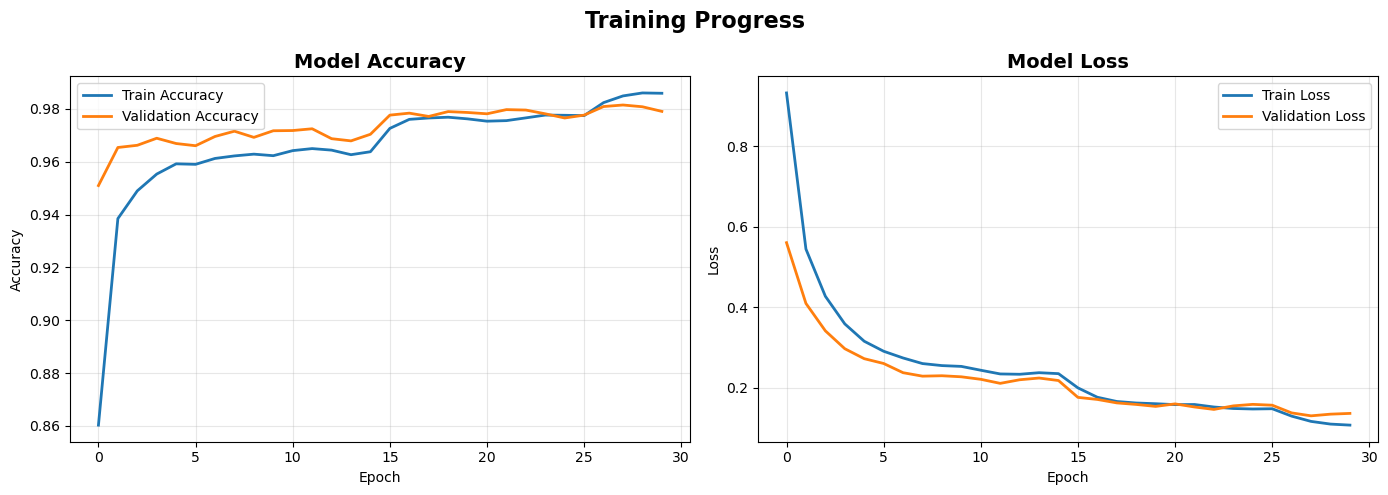

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
ax1.set_title('Model Accuracy', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'], label='Train Loss', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax2.set_title('Model Loss', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Training Progress', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('models/training_history.png')
plt.show()


# Confusion Matrix

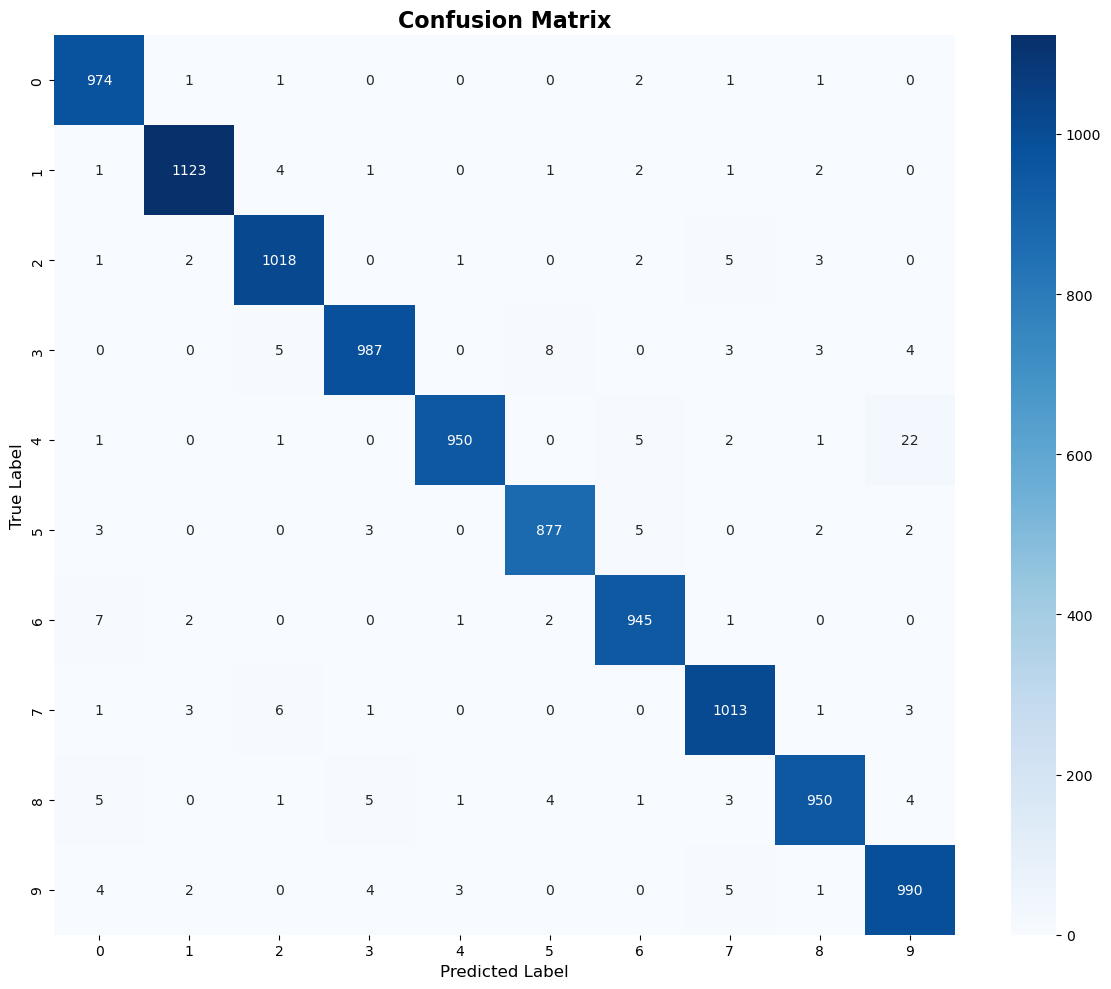

In [ ]:
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('models/confusion_matrix.png')
plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.99      0.98      1032
           3       0.99      0.98      0.98      1010
           4       0.99      0.97      0.98       982
           5       0.98      0.98      0.98       892
           6       0.98      0.99      0.98       958
           7       0.98      0.99      0.98      1028
           8       0.99      0.98      0.98       974
           9       0.97      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000

